# Projekat: Klasifikacija pecuraka (Edible vs Poisinous)
**Tema**: Nadgledano ucenje - Klasifikacija

**Dataset**: [Mushroom Classification (Kaggle - Biology)](https://www.kaggle.com/datasets/uciml/mushroom-classification)

## Definicija problema i ucitavanje podataka
- Cilj: Na osnovu fizickih karakteristika pecurke predvideti da li je otrovna ili jestiva.
- Ucitavanje biblioteka i skupa podataka.


In [154]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/mushrooms.csv')

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Opis atributa 

- <b>class</b>: Klasa (Cilj): edible=e (jestiva), poisonous=p (otrovna)

- <b>cap-shape</b>: Oblik sesira: bell=b (zvonast), conical=c (kupast), convex=x (ispupcen), flat=f (ravan), knobbed=k (kvrgav/izbocen), sunken=s (udubljen)

- <b>cap-surface</b>: Povrsina sesira: fibrous=f (vlaknasta), grooves=g (zljebovita), scaly=y (ljuspasta), smooth=s (glatka)

- <b>cap-color</b>: Boja sesira: brown=n (braon), buff=b (bez/zutosmedja), cinnamon=c (cimet), gray=g (siva), green=r (zelena), pink=p (roze), purple=u (ljubicasta), red=e (crvena), white=w (bela), yellow=y (zuta)

- <b>bruises</b>: Uboji (modrice/ostecenja): bruises=t (ima), no=f (nema)

- <b>odor</b>: Miris: almond=a (badem), anise=l (anis), creosote=c (kreozot/dim), fishy=y (riba), foul=f (uzasan/trulez), musty=m (budjav), none=n (bez mirisa), pungent=p (ostar/ljut), spicy=s (zacinski)

- <b>gill-attachment</b>: Prianjanje listica (za drsku): attached=a (pripojeni), descending=d (silazni), free=f (slobodni), notched=n (nazubljeni)

- <b>gill-spacing</b>: Razmak listica: close=c (blizu), crowded=w (zbijeni), distant=d (razmaknuti)

- <b>gill-size</b>: Velicina listica: broad=b (siroki), narrow=n (uski)

- <b>gill-color</b>: Boja listica: black=k (crna), brown=n (braon), buff=b (bez), chocolate=h (cokoladna), gray=g (siva), green=r (zelena), orange=o (narandzasta), pink=p (roze), purple=u (ljubicasta), red=e (crvena), white=w (bela), yellow=y (zuta)

- <b>stalk-shape</b>: Oblik drske: enlarging=e (prosiruje se), tapering=t (suzava se)

- <b>stalk-root</b>: Koren drske: bulbous=b (lukovicast), club=c (batinast), cup=u (casast), equal=e (jednak), rhizomorphs=z (rizomorfi/koncici), rooted=r (ukorenjen), missing=? (nepoznato/nedostaje)

- <b>stalk-surface-above-ring</b>: Povrsina drske iznad prstena: fibrous=f (vlaknasta), scaly=y (ljuspasta), silky=k (svilenkasta), smooth=s (glatka)

- <b>stalk-surface-below-ring</b>: Povrsina drske ispod prstena: fibrous=f (vlaknasta), scaly=y (ljuspasta), silky=k (svilenkasta), smooth=s (glatka)

- <b>stalk-color-above-ring</b>: Boja drske iznad prstena: brown=n (braon), buff=b (bez), cinnamon=c (cimet), gray=g (siva), orange=o (narandzasta), pink=p (roze), red=e (crvena), white=w (bela), yellow=y (zuta)

- <b>stalk-color-below-ring</b>: Boja drske ispod prstena: (iste boje kao iznad)

- <b>veil-type</b>: Tip vela: partial=p (delimican), universal=u (univerzalan)

- <b>veil-color</b>: Boja vela: brown=n (braon), orange=o (narandzasta), white=w (bela), yellow=y (zuta)

- <b>ring-number</b>: Broj prstenova: none=n (nema), one=o (jedan), two=t (dva)

- <b>ring-type</b>: Tip prstena: cobwebby=c (paucinast), evanescent=e (nestalan/prolazan), flaring=f (siri se/levkast), large=l (veliki), none=n (nema), pendant=p (viseci), sheathing=s (obavijen), zone=z (zona)

- <b>spore-print-color</b>: Boja spora (otisak): black=k (crna), brown=n (braon), buff=b (bez), chocolate=h (cokoladna), green=r (zelena), orange=o (narandzasta), purple=u (ljubicasta), white=w (bela), yellow=y (zuta)

- <b>population</b>: Populacija (kako rastu): abundant=a (izobilna), clustered=c (grupisana/klasteri), numerous=n (brojna), scattered=s (rastrkana), several=v (nekoliko), solitary=y (usamljena)

- <b>habitat</b>: Staniste: grasses=g (trava), leaves=l (lisce), meadows=m (livade), paths=p (staze), urban=u (urbano), waste=w (otpad), woods=d (suma)

### Prikaz tipova podataka

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

### Prikaz vrste korena

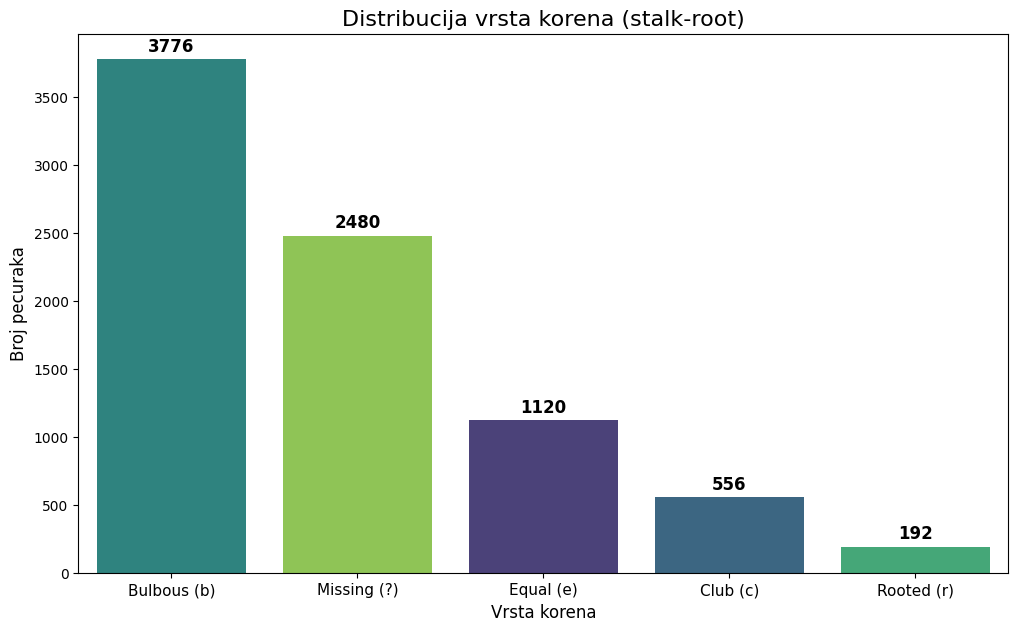

In [156]:
plt.figure(figsize=(12, 7))

df_viz = df.copy()

mapping = {
    'b': 'Bulbous (b)',
    '?': 'Missing (?)',
    'e': 'Equal (e)',
    'c': 'Club (c)',
    'r': 'Rooted (r)'
}

df_viz['stalk-root'] = df_viz['stalk-root'].map(mapping)

ax = sns.countplot(
    x='stalk-root', 
    data=df_viz, 
    hue='stalk-root',
    legend=False,
    palette='viridis',
    order=df_viz['stalk-root'].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container, fontsize=12, padding=3, fontweight='bold')

plt.title('Distribucija vrsta korena (stalk-root)', fontsize=16)
plt.xlabel('Vrsta korena', fontsize=12)
plt.ylabel('Broj pecuraka', fontsize=12)
plt.xticks(fontsize=11)

plt.show()

### Promene tipova podataka u integer

In [157]:
encoding = LabelEncoder

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   int64
 1   cap-shape                 8124 non-null   int64
 2   cap-surface               8124 non-null   int64
 3   cap-color                 8124 non-null   int64
 4   bruises                   8124 non-null   int64
 5   odor                      8124 non-null   int64
 6   gill-attachment           8124 non-null   int64
 7   gill-spacing              8124 non-null   int64
 8   gill-size                 8124 non-null   int64
 9   gill-color                8124 non-null   int64
 10  stalk-shape               8124 non-null   int64
 11  stalk-root                8124 non-null   int64
 12  stalk-surface-above-ring  8124 non-null   int64
 13  stalk-surface-below-ring  8124 non-null   int64
 14  stalk-color-above-ring    8124 non-null 

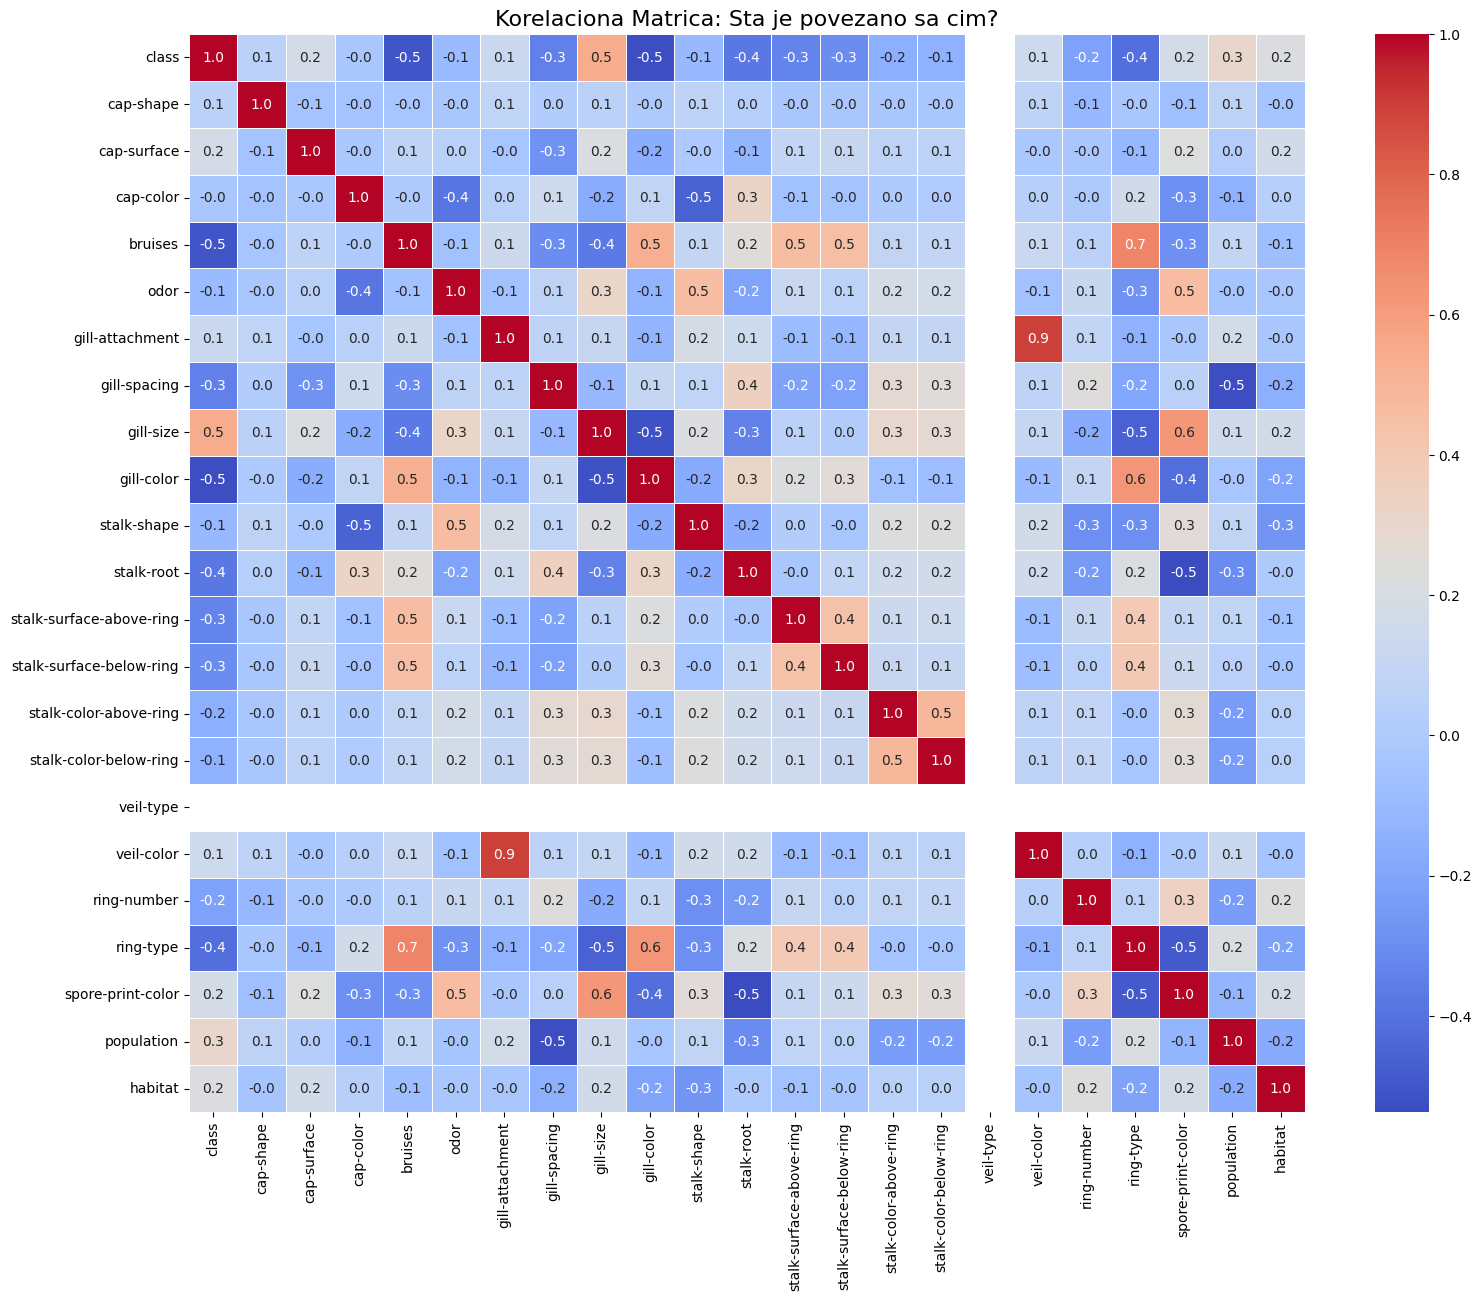

In [158]:
plt.figure(figsize=(18, 14))

sns.heatmap(df.corr(), annot=True, fmt='.1f', cmap='coolwarm', linewidths=0.5)

plt.title('Korelaciona Matrica: Sta je povezano sa cim?', fontsize=16)
plt.show()

Primecujemo u grafu kako veil-type ne postoji, mozemo da ga izbacimo

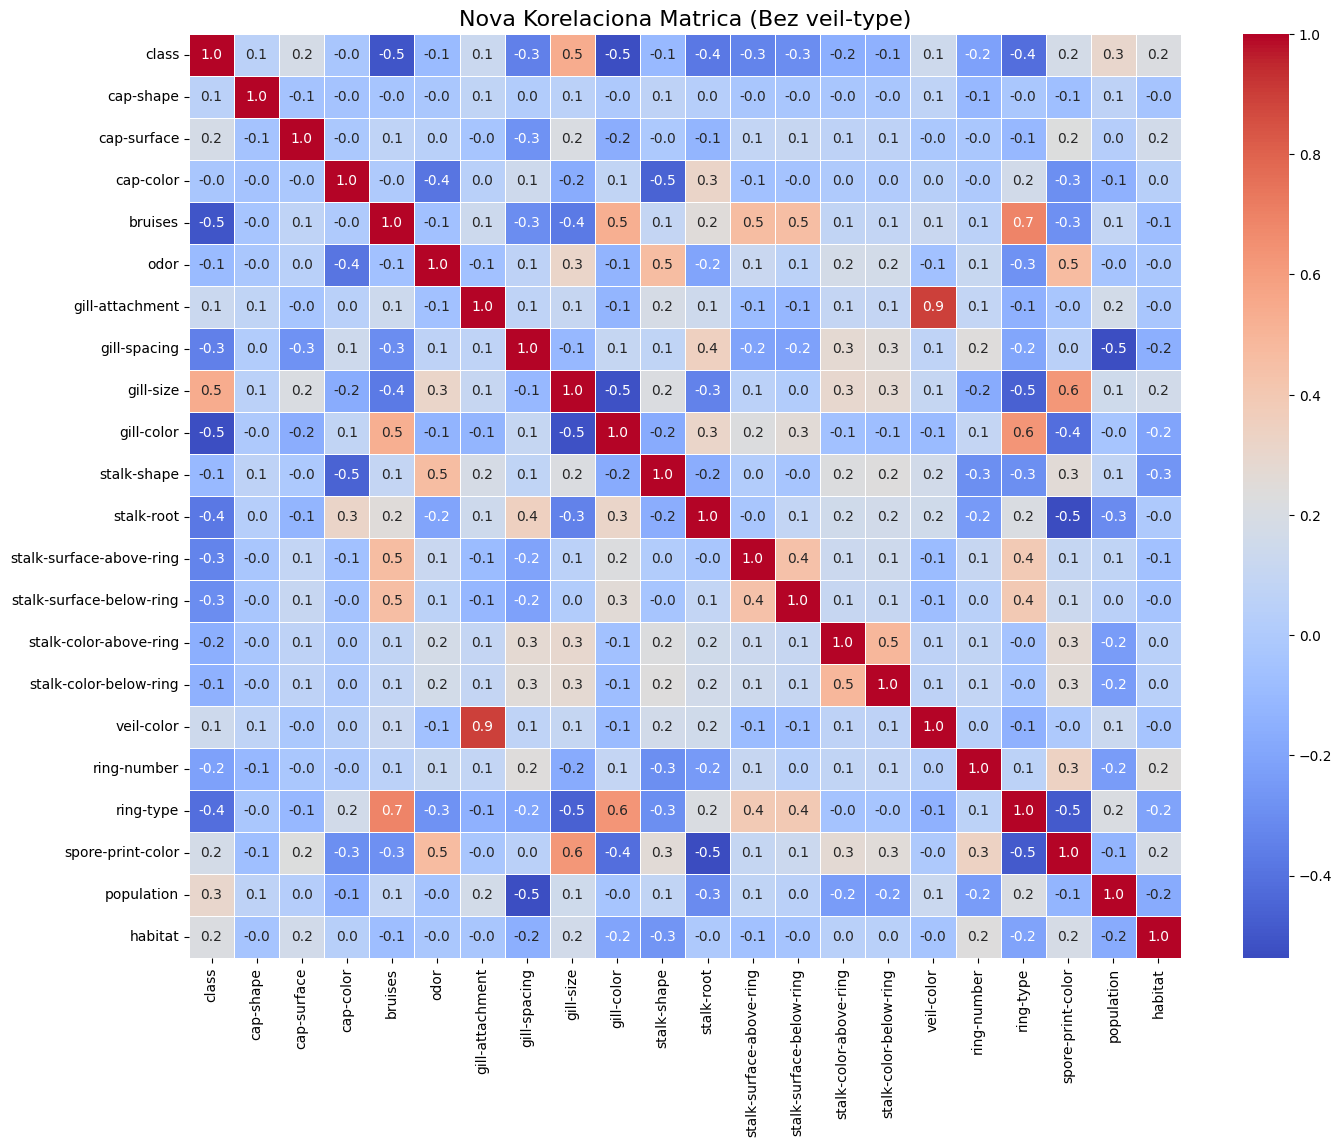

In [159]:
if 'veil-type' in df.columns:
    df = df.drop('veil-type', axis=1)

corr_matrix = df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.1f', cmap='coolwarm', linewidths=0.5)
plt.title('Nova Korelaciona Matrica (Bez veil-type)', fontsize=16)
plt.show()

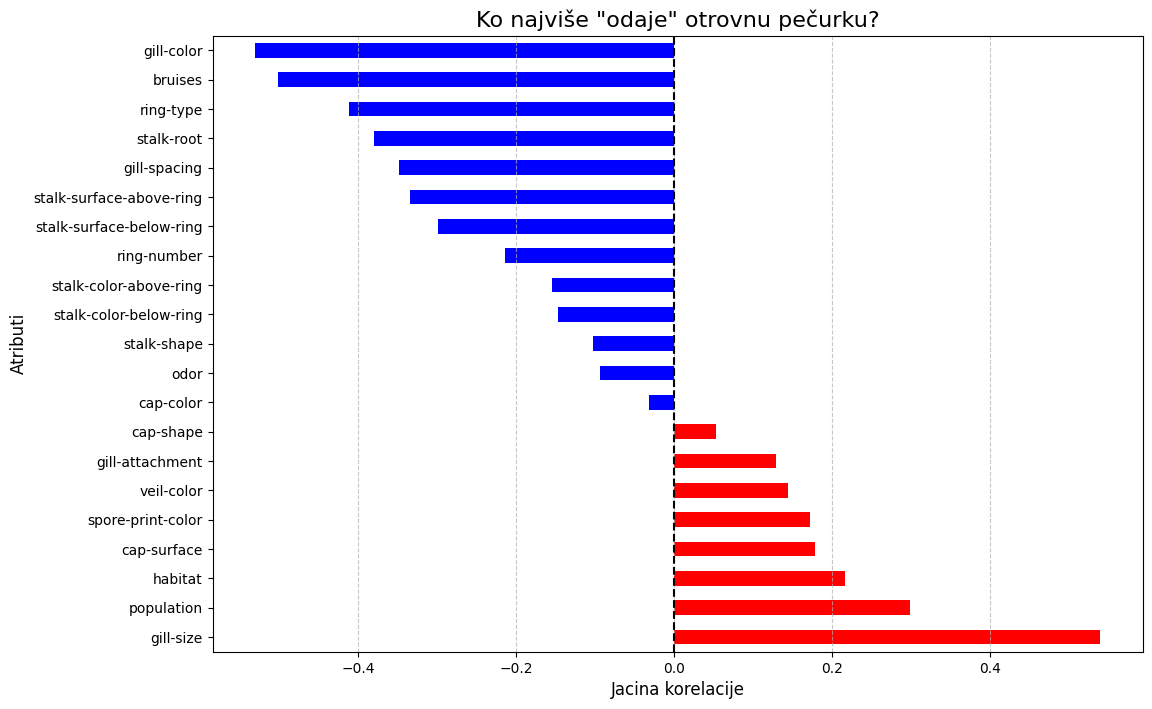

In [160]:
target_corr = df.corr()['class'].sort_values(ascending=False)

target_corr = target_corr.drop('class')

plt.figure(figsize=(12, 8))
target_corr.plot(kind='barh', color=target_corr.apply(lambda x: 'red' if x > 0 else 'blue'))

plt.title('Ko najviše "odaje" otrovnu pečurku?', fontsize=16)
plt.xlabel('Jacina korelacije', fontsize=12)
plt.ylabel('Atributi', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

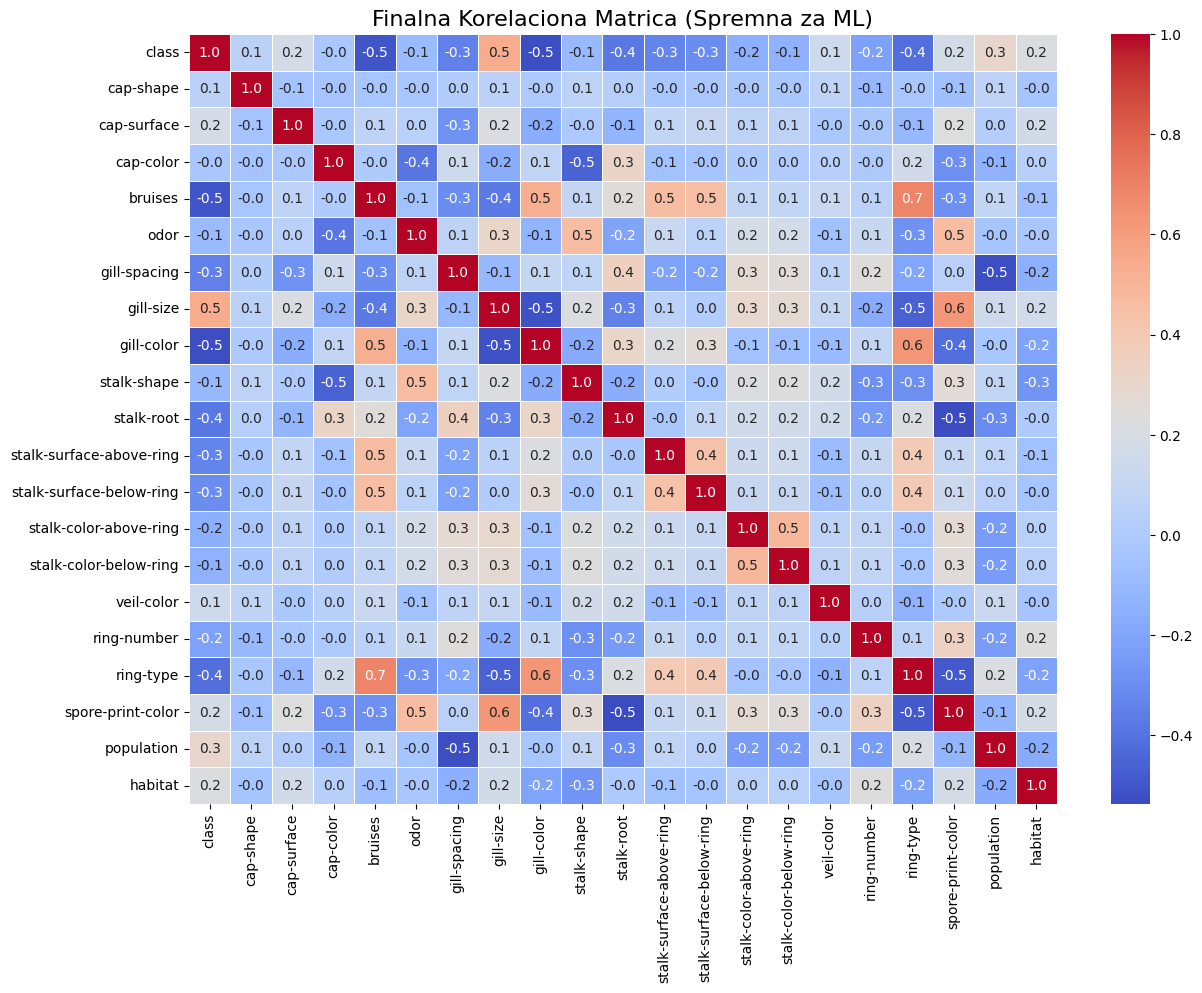

In [161]:
if 'gill-attachment' in df.columns:
    df_encoded = df.drop('gill-attachment', axis=1)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.1f', cmap='coolwarm', linewidths=0.5)
plt.title('Finalna Korelaciona Matrica (Spremna za ML)', fontsize=16)
plt.show()

In [162]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,...,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000
mean,0.482029,3.348104,1.827671,4.504677,0.415559,4.144756,0.974151,0.161497,0.309207,4.810684,...,1.575086,1.603644,5.816347,5.794682,1.965534,1.069424,2.291974,3.596750,3.644018,1.508616
std,0.499708,1.604329,1.229873,2.545821,0.492848,2.103729,0.158695,0.368011,0.462195,3.540359,...,0.621459,0.675974,1.901747,1.907291,0.242669,0.271064,1.801672,2.382663,1.252082,1.719975
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,3.000000,0.000000,2.000000,1.000000,0.000000,0.000000,2.000000,...,1.000000,1.000000,6.000000,6.000000,2.000000,1.000000,0.000000,2.000000,3.000000,0.000000
50%,0.000000,3.000000,2.000000,4.000000,0.000000,5.000000,1.000000,0.000000,0.000000,5.000000,...,2.000000,2.000000,7.000000,7.000000,2.000000,1.000000,2.000000,3.000000,4.000000,1.000000
75%,1.000000,5.000000,3.000000,8.000000,1.000000,5.000000,1.000000,0.000000,1.000000,7.000000,...,2.000000,2.000000,7.000000,7.000000,2.000000,1.000000,4.000000,7.000000,4.000000,2.000000
max,1.000000,5.000000,3.000000,9.000000,1.000000,8.000000,1.000000,1.000000,1.000000,11.000000,...,3.000000,3.000000,8.000000,8.000000,3.000000,2.000000,4.000000,8.000000,5.000000,6.000000
